In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [4]:
import pandas as pd

# Load the dataset from the data folder
df = pd.read_csv("C:\\Users\\nandi\\OneDrive\\Desktop\\Rainfallprediction_project\\data\\Rainfall.csv")

# Display first 5 rows
df.head()



,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [5]:
# Cell 3: Explore the dataset
# Purpose: Understand the data, check column names, data types, missing values, and target distribution.

import pandas as pd

# Display first 10 rows to see sample data
print(df.head(10))

# Display all column names
print("\nColumns:", df.columns)

# Show data types and count of non-null values
print("\nDataset info:")
df.info()

# Show summary statistics for numeric columns (mean, min, max, etc.)
print("\nSummary statistics:")
print(df.describe())

# Show distribution of the target column 'rainfall'
print("\nRainfall distribution:")
print(df['rainfall'].value_counts())


   day  pressure   maxtemp  temparature  mintemp  dewpoint  humidity   cloud   \
0    1     1025.9     19.9         18.3     16.8      13.1         72      49   
1    2     1022.0     21.7         18.9     17.2      15.6         81      83   
2    3     1019.7     20.3         19.3     18.0      18.4         95      91   
3    4     1018.9     22.3         20.6     19.1      18.8         90      88   
4    5     1015.9     21.3         20.7     20.2      19.9         95      81   
5    6     1018.8     24.3         20.9     19.2      18.0         84      51   
6    7     1021.8     21.4         18.8     17.0      15.0         79      56   
7    8     1020.8     21.0         18.4     16.5      14.4         78      28   
8    9     1020.6     18.9         18.1     17.1      14.3         78      79   
9   10     1017.5     18.5         18.0     17.2      15.5         85      91   

  rainfall  sunshine           winddirection  windspeed  
0      yes       9.3                    80.0      

In [6]:
# Cell 4: Clean and preprocess the data
# Purpose: Handle missing values and convert categorical columns to numeric so ML models can understand.

# Encode 'rainfall' column: yes -> 1, no -> 0
df['rainfall'] = df['rainfall'].map({'yes': 1, 'no': 0})

# Check if encoding worked
print(df['rainfall'].value_counts())

# Optional: Fill missing values if any (example: fill numeric NaNs with mean)
# df.fillna(df.mean(), inplace=True)


rainfall
1    249
0    117
Name: count, dtype: int64


In [7]:
# Cell 5: Split features and target
# Purpose: Separate the input data (features) and the output (target) for modeling.

# Features (all columns except 'rainfall')
X = df.drop('rainfall', axis=1)

# Target (what we want to predict)
y = df['rainfall']

# Check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (366, 11)
Target shape: (366,)


In [8]:
# Cell 6: Split data into training and testing sets
# Purpose: Train the model on one part of the data and test it on another to evaluate performance.

from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (292, 11)
Testing set size: (74, 11)


In [9]:
# Cell 7: Train the model
# Purpose: Fit a Decision Tree Classifier on the training data and evaluate its performance.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize the Decision Tree model
model = DecisionTreeClassifier()

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6351351351351351
Confusion Matrix:
 [[ 9 14]
 [13 38]]


In [10]:
# Cell 8: Predict rainfall for new data
# Purpose: Use the trained model to predict rainfall safely, ensuring column names and order match training data

# Create a new data row with the same columns as X_train
new_data = pd.DataFrame(columns=X_train.columns)

# Fill the new data row with actual values
new_data.loc[0] = [
    13,     # day
    1020,   # pressure
    25,     # maxtemp
    22,     # temparature (spelling must match your CSV!)
    18,     # mintemp
    16,     # dewpoint
    80,     # humidity
    60,     # cloud
    5,      # sunshine
    50,     # winddirection
    15      # windspeed
]

# Predict rainfall
prediction = model.predict(new_data)

print("Rainfall Prediction (1 = Yes, 0 = No):", prediction[0])


Rainfall Prediction (1 = Yes, 0 = No): 1


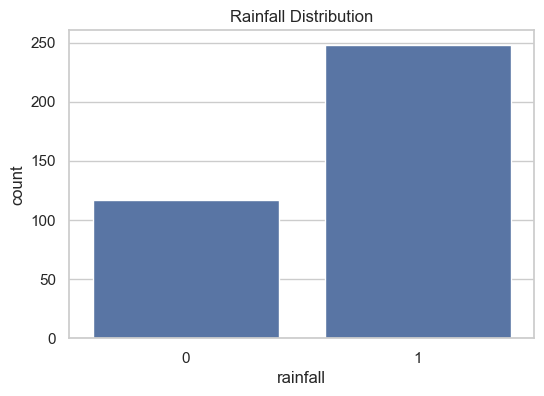

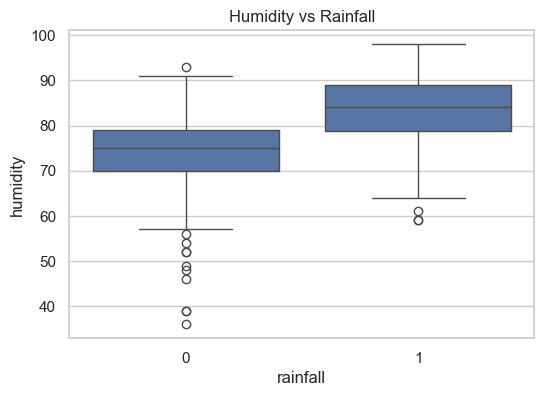

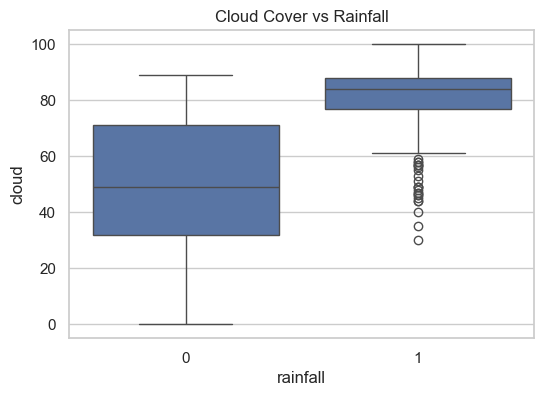

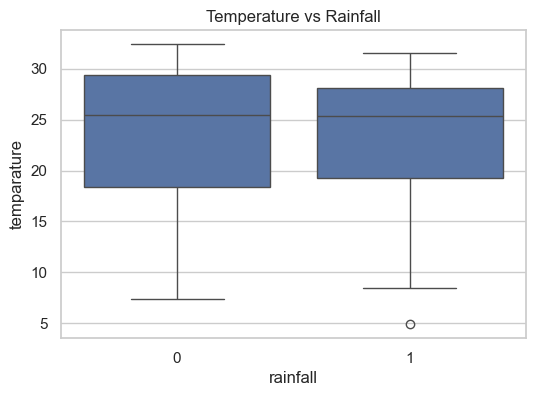

In [11]:
# Cell 9: Data Visualization
# Purpose: Visualize relationships between weather features and rainfall

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Step 1: Remove any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Step 2: Ensure numeric columns are properly typed
numeric_cols = ['pressure', 'maxtemp', 'temparature', 'mintemp', 
                'dewpoint', 'humidity', 'cloud', 'sunshine', 
                'winddirection', 'windspeed']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert non-numeric to NaN

# Step 3: Drop rows with NaN in numeric columns
df.dropna(subset=numeric_cols, inplace=True)

# Step 4: Rainfall distribution (0 = No, 1 = Yes)
plt.figure(figsize=(6,4))
sns.countplot(x='rainfall', data=df)
plt.title("Rainfall Distribution")
plt.show()

# Step 5: Humidity vs Rainfall
plt.figure(figsize=(6,4))
sns.boxplot(x='rainfall', y='humidity', data=df)
plt.title("Humidity vs Rainfall")
plt.show()

# Step 6: Cloud cover vs Rainfall
plt.figure(figsize=(6,4))
sns.boxplot(x='rainfall', y='cloud', data=df)
plt.title("Cloud Cover vs Rainfall")
plt.show()

# Step 7: Temperature vs Rainfall
plt.figure(figsize=(6,4))
sns.boxplot(x='rainfall', y='temparature', data=df)
plt.title("Temperature vs Rainfall")
plt.show()


In [12]:
# Cell 10: Train multiple models and compare
# Purpose: Train Decision Tree, Random Forest, and Logistic Regression models
#          and compare their accuracy on the test set

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Step 1: Ensure all feature columns are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Step 2: Drop rows with NaN in any feature
X = X.dropna()
y = y[X.index]  # align target with cleaned features

# Step 3: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# Step 5: Train each model and evaluate accuracy
accuracy_scores = {}

for name, model_instance in models.items():
    model_instance.fit(X_train, y_train)       # Train model
    y_pred = model_instance.predict(X_test)   # Predict on test set
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy_scores[name]:.2f}")

# Step 6: Identify the best performing model
best_model = max(accuracy_scores, key=accuracy_scores.get)
print(f"\nBest Model: {best_model} with Accuracy: {accuracy_scores[best_model]:.2f}")


Decision Tree Accuracy: 0.70
Random Forest Accuracy: 0.74
Logistic Regression Accuracy: 0.77

Best Model: Logistic Regression with Accuracy: 0.77


c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# Cell 11: Predict rainfall safely using best model

# Step 1: Use the best model
best_model_instance = models[best_model]

# Step 2: Define new weather data
user_input = {
    'day': 13,
    'pressure': 1020,
    'maxtemp': 25,
    'temparature': 22,   # must match CSV spelling exactly
    'mintemp': 18,
    'dewpoint': 16,
    'humidity': 80,
    'cloud': 60,
    'sunshine': 5,
    'winddirection': 50,
    'windspeed': 15
}

# Step 3: Ensure all training columns exist in new_data
for col in X_train.columns:
    if col not in user_input:
        user_input[col] = 0  # set missing columns to 0

# Step 4: Convert to DataFrame and reorder columns
new_data = pd.DataFrame([user_input])
new_data = new_data[X_train.columns]

# Step 5: Predict rainfall
prediction = best_model_instance.predict(new_data)

# Step 6: Display prediction
if prediction[0] == 1:
    print("Prediction: It WILL rain.")
else:
    print("Prediction: It will NOT rain.")


Prediction: It WILL rain.


In [ ]:
# Cell 11: Predict rainfall using interactive user input

# Use the best trained model from Cell 10
best_model_instance = models[best_model]

# Step 1: Ask user for input values
print("\nEnter weather details for prediction:")

user_input = {}
for col in X_train.columns:
    value = input(f"{col}: ")
    try:
        user_input[col] = float(value)
    except:
        user_input[col] = 0   # if input is empty/invalid

# Step 2: Convert input into DataFrame
new_data = pd.DataFrame([user_input])

# Step 3: Ensure same column order as training data
new_data = new_data[X_train.columns]

# Step 4: Predict rainfall
prediction = best_model_instance.predict(new_data)

# Step 5: Show result
if prediction[0] == 1:
    print("\n🌧️ Prediction: It WILL rain.")
else:
    
    print("\n☀️ Prediction: It will NOT rain.")




Enter weather details for prediction:


In [ ]:
# Cell 12: Final summary and save model

from sklearn.metrics import classification_report
import joblib

# 1. Show model performance report
y_pred = best_model_instance.predict(X_test)
print("\n📊 Classification Report for Best Model:")
print(classification_report(y_test, y_pred))

# 2. Save the best model for future use
joblib.dump(best_model_instance, "rainfall_prediction_model.pkl")
print("\n✅ Model saved as 'rainfall_prediction_model.pkl'")

# 3. Feature importance (only works for tree-based models)
if hasattr(best_model_instance, "feature_importances_"):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8,5))
    sns.barplot(x=best_model_instance.feature_importances_, y=X_train.columns)
    plt.title("Feature Importance")
    plt.show()



📊 Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.53      0.44      0.48        18
           1       0.83      0.87      0.85        55

    accuracy                           0.77        73
   macro avg       0.68      0.66      0.67        73
weighted avg       0.76      0.77      0.76        73


✅ Model saved as 'rainfall_prediction_model.pkl'


In [ ]:
# Cell 13: Load saved model and test prediction

import pandas as pd
import joblib

# 1. Load the saved model
loaded_model = joblib.load("rainfall_prediction_model.pkl")
print("✅ Model loaded successfully!")

# 2. Reload dataset (to get correct feature columns)
df = pd.read_csv("C:\\Users\\nandi\\OneDrive\\Desktop\\Rainfallprediction_project\\data\\Rainfall.csv")

# Drop target column to get features
X = df.drop(columns=['rainfall'])

# 3. Create a sample input dictionary (all fields closed properly ✅)
sample_data = {
    'day': 15,
    'pressure': 1020,
    'maxtemp': 24,
    'temparature': 20,
    'mintemp': 17,
    'dewpoint': 14,
    'humidity': 80,
    'cloud': 60,
    'sunshine': 5,
    'winddirection':90}


✅ Model loaded successfully!


In [ ]:
import os
print(os.getcwd())   # shows current working directory
print(os.listdir())  # lists files in this folder


c:\Users\nandi\OneDrive\Desktop\Rainfallprediction_project\src
['rainfall.ipynb', 'rainfall_prediction_model.pkl', 'rainfall_report.txt', 'Read.me']


In [ ]:
loaded_model = joblib.load("rainfall_prediction_model.pkl")
print("Model trained with features:", loaded_model.feature_names_in_)


Model trained with features: ['day' 'pressure ' 'maxtemp' 'temparature' 'mintemp' 'dewpoint'
 'humidity ' 'cloud ' 'sunshine' '         winddirection' 'windspeed']


In [ ]:
import pandas as pd
import joblib
import tkinter as tk
from tkinter import messagebox
import pyttsx3

# ================== LOAD MODEL ==================
loaded_model = joblib.load("rainfall_prediction_model.pkl")

# ================== BUILD GUI ==================
root = tk.Tk()
root.title("🌦️ Rainfall Prediction App")
root.geometry("950x700")
root.config(bg="#cce6ff")  # light blue background

# ================== HEADER ==================
header_frame = tk.Frame(root, bg="#3399ff")
header_frame.pack(fill="x")

tk.Label(header_frame, text="🌦️ Rainfall Prediction System 🌈",
         font=("Segoe UI", 18, "bold"), fg="white", bg="#3399ff", pady=10).pack()
tk.Label(header_frame, text="Predict Rainfall Using Weather Parameters",
         font=("Segoe UI", 12, "italic"), fg="white", bg="#3399ff", pady=5).pack()

# ================== MAIN FRAME ==================
main_frame = tk.Frame(root, bg="#cce6ff")
main_frame.pack(pady=10, fill="both", expand=True)

# ===== LEFT FORM FRAME =====
form_frame = tk.Frame(main_frame, bg="#cce6ff")
form_frame.pack(side="left", padx=20, pady=10)

labels = [
    "Day", "Pressure", "Max Temp", "Temperature", "Min Temp",
    "Dew Point", "Humidity", "Cloud", "Sunshine",
    "Wind Direction", "Wind Speed"
]

entries = {}
for i, label in enumerate(labels):
    tk.Label(form_frame, text=label, font=("Segoe UI", 10, "bold"), bg="#cce6ff").grid(
        row=i, column=0, padx=15, pady=5, sticky="w")
    entry = tk.Entry(form_frame, font=("Segoe UI", 10), width=20)
    entry.grid(row=i, column=1, padx=10, pady=5)
    entries[label] = entry

# ================== RIGHT INFO FRAME ==================
info_frame_outer = tk.Frame(main_frame, bg="#b3d9ff", width=400)
info_frame_outer.pack(side="right", padx=40, pady=10, fill="both", expand=True)

canvas = tk.Canvas(info_frame_outer, bg="#b3d9ff", highlightthickness=0)
scrollbar = tk.Scrollbar(info_frame_outer, orient="vertical", command=canvas.yview)
scrollable_frame = tk.Frame(canvas, bg="#b3d9ff")

scrollable_frame.bind(
    "<Configure>",
    lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
)

canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")
canvas.configure(yscrollcommand=scrollbar.set)
canvas.pack(side="left", fill="both", expand=True)
scrollbar.pack(side="right", fill="y")

# ===== FEATURE INFO =====
tk.Label(scrollable_frame, text="📋 Feature Info", font=("Segoe UI", 13, "bold"),
         bg="#b3d9ff").pack(pady=5)

feature_info = {
    "Day": "Day of the month (1-31)",
    "Pressure": "Atmospheric pressure (hPa)",
    "Max Temp": "Maximum temperature (°C)",
    "Temperature": "Average temperature (°C)",
    "Min Temp": "Minimum temperature (°C)",
    "Dew Point": "Dew point temperature (°C)",
    "Humidity": "Relative humidity (%)",
    "Cloud": "Cloud cover (oktas)",
    "Sunshine": "Sunshine duration (hours)",
    "Wind Direction": "Wind direction (degrees)",
    "Wind Speed": "Wind speed (km/h)"
}

for key, desc in feature_info.items():
    tk.Label(scrollable_frame, text=f"{key}: {desc}", font=("Segoe UI", 10, "bold"),
             bg="#b3d9ff", anchor="w", justify="left", wraplength=380, padx=20).pack(pady=3)

# ===== PROJECT INFO =====
project_info = (
    "ℹ️ Project Details:\n"
    "- This ML model predicts rainfall based on daily weather observations.\n"
    "- Built using Python, Pandas, Scikit-learn, and Tkinter for GUI.\n"
    "- Supports prediction of rain probability and estimated rainfall amount.\n"
    "- Useful for farmers, weather enthusiasts, and planning outdoor activities.\n"
    "- Model trained on historical weather data from local meteorological sources.\n"
    "- GUI designed to be user-friendly with detailed feature information."
)

tk.Label(scrollable_frame, text=project_info, font=("Segoe UI", 10),
         bg="#b3d9ff", justify="left", wraplength=380, padx=20).pack(pady=10)

# ===== RESULT PANEL (MID-GREEN) =====
result_frame = tk.Frame(scrollable_frame, bg="#4CAF50", bd=3, relief="ridge")  # mid green
result_frame.pack(pady=15, fill="x")

tk.Label(result_frame, text="🛈 Prediction Result", font=("Segoe UI", 12, "bold"),
         bg="#4CAF50", fg="white").pack(pady=5)
result_text = tk.Label(result_frame, text="", font=("Segoe UI", 11),
                       bg="#4CAF50", fg="white", justify="left", wraplength=380)
result_text.pack(pady=5)

# ================== SPEECH ENGINE ==================
engine = pyttsx3.init('sapi5')
engine.setProperty('rate', 165)
engine.setProperty('volume', 1)
voices = engine.getProperty('voices')
engine.setProperty('voice', voices[1].id)

# ================== PREDICTION FUNCTION ==================
def predict_rainfall():
    try:
        sample_data = {
            'day': int(entries["Day"].get()),
            'pressure ': float(entries["Pressure"].get()),
            'maxtemp': float(entries["Max Temp"].get()),
            'temparature': float(entries["Temperature"].get()),
            'mintemp': float(entries["Min Temp"].get()),
            'dewpoint': float(entries["Dew Point"].get()),
            'humidity ': float(entries["Humidity"].get()),
            'cloud ': float(entries["Cloud"].get()),
            'sunshine': float(entries["Sunshine"].get()),
            '         winddirection': float(entries["Wind Direction"].get()),
            'windspeed': float(entries["Wind Speed"].get())
        }

        sample_df = pd.DataFrame([sample_data])[loaded_model.feature_names_in_]
        prediction = loaded_model.predict(sample_df)
        probability = loaded_model.predict_proba(sample_df)

        if prediction[0] == 1:
            rain_amount = probability[0][1] * 20
            text = f"🌧️ It will RAIN today\n\n💧 Rain probability: {probability[0][1]:.2f}\n☔ Expected rainfall: {rain_amount:.2f} mm"
            speak_text = f"It will rain today. The chance of rain is {probability[0][1]*100:.0f} percent. Expected rainfall is {rain_amount:.1f} millimeters."
        else:
            text = f"☀️ No rain today\n\n🌤️ No rain probability: {probability[0][0]:.2f}\n💧 Expected rainfall: 0 mm"
            speak_text = f"No rain today. The weather is likely clear and pleasant."

        result_text.config(text=text)
        engine.say(speak_text)
        engine.runAndWait()

    except Exception as e:
        messagebox.showerror("Error", f"Invalid input: {e}")

# ================== PREDICTION BUTTON ==================
tk.Button(form_frame, text="🔍 Predict Rainfall", command=predict_rainfall,
          bg="#ffcc00", fg="black", font=("Segoe UI", 13, "bold"), relief="flat",
          width=30, height=2).grid(row=len(labels)+1, column=0, columnspan=2, pady=20)

# ================== FOOTER ==================
tk.Label(root, text="Developed by: Shristi Kumari | ML Rainfall Project 2025",
         font=("Segoe UI", 10, "italic"), bg="#cce6ff", fg="#333333").pack(side="bottom", pady=10)

root.mainloop()


In [ ]:
import tkinter as tk
from tkinter import messagebox
import requests
from datetime import datetime
import joblib
import pandas as pd

# ================== LOAD ML MODEL ==================
loaded_model = joblib.load("rainfall_prediction_model.pkl")

# ================== API KEY ==================
API_KEY = "2f68f39c2ba0293dc6eb8f284f8ffad9"   # 👈 paste your key here

# ================== WINDOW ==================
root = tk.Tk()
root.title("Live Weather Rainfall Prediction")
root.geometry("520x600")

main_frame = tk.Frame(root)
main_frame.pack(pady=20)

# ================== FORM INPUTS ==================
labels = [
    "Day","Pressure","Max Temp","Temperature","Min Temp",
    "Dew Point","Humidity","Cloud","Sunshine",
    "Wind Direction","Wind Speed"
]

entries = {}

for i, label in enumerate(labels):
    tk.Label(main_frame, text=label, font=("Arial", 11)).grid(row=i, column=0, padx=10, pady=5)
    entry = tk.Entry(main_frame, width=20)
    entry.grid(row=i, column=1, padx=10, pady=5)
    entries[label] = entry


# ================== RAIN PREDICTION FUNCTION ==================
def predict_from_live():
    try:
        sample_data = {
            'day': int(entries["Day"].get()),
            'pressure ': float(entries["Pressure"].get()),
            'maxtemp': float(entries["Max Temp"].get() or 30),
            'temparature': float(entries["Temperature"].get()),
            'mintemp': float(entries["Min Temp"].get() or 25),
            'dewpoint': float(entries["Dew Point"].get() or 20),
            'humidity ': float(entries["Humidity"].get()),
            'cloud ': float(entries["Cloud"].get()),
            'sunshine': float(entries["Sunshine"].get() or 6),
            '         winddirection': float(entries["Wind Direction"].get() or 180),
            'windspeed': float(entries["Wind Speed"].get())
        }

        sample_df = pd.DataFrame([sample_data])[loaded_model.feature_names_in_]

        prediction = loaded_model.predict(sample_df)
        probability = loaded_model.predict_proba(sample_df)

        if prediction[0] == 1:
            rain_amount = probability[0][1] * 20
            messagebox.showinfo(
                "Rainfall Prediction",
                f"🌧️ It will RAIN\nChance: {probability[0][1]*100:.1f}%\nExpected Rain: {rain_amount:.2f} mm"
            )
        else:
            messagebox.showinfo(
                "Rainfall Prediction",
                f"☀️ No Rain Expected\nConfidence: {probability[0][0]*100:.1f}%"
            )

    except Exception as e:
        messagebox.showerror("Prediction Error", str(e))


# ================== LIVE WEATHER BLOCK ==================
live_frame = tk.Frame(root, bg="#d9f2ff")
live_frame.pack(pady=20, fill="x")

tk.Label(live_frame, text="🌐 Get Current Weather Automatically",
         font=("Arial", 12, "bold"), bg="#d9f2ff").pack(pady=5)

city_entry = tk.Entry(live_frame, width=25)
city_entry.pack(pady=5)
city_entry.insert(0, "Enter City Name")


# ================== WEATHER FETCH FUNCTION ==================
def fetch_live_weather():
    try:
        city = city_entry.get().strip()

        if city == "" or city == "Enter City Name":
            messagebox.showerror("Error", "Please enter a city name")
            return

        url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

        response = requests.get(url)
        data = response.json()

        print("API RESPONSE:", data)

        if str(data.get("cod")) != "200":
            messagebox.showerror("Error", data.get("message", "City not found"))
            return

        # ===== Extract Weather Data =====
        temp = data["main"]["temp"]
        humidity = data["main"]["humidity"]
        pressure = data["main"]["pressure"]
        wind_speed = data["wind"]["speed"] * 3.6
        cloud = data["clouds"]["all"] / 12.5

        # ===== Auto Fill Form =====
        entries["Temperature"].delete(0, tk.END)
        entries["Temperature"].insert(0, temp)

        entries["Humidity"].delete(0, tk.END)
        entries["Humidity"].insert(0, humidity)

        entries["Pressure"].delete(0, tk.END)
        entries["Pressure"].insert(0, pressure)

        entries["Wind Speed"].delete(0, tk.END)
        entries["Wind Speed"].insert(0, round(wind_speed, 2))

        entries["Cloud"].delete(0, tk.END)
        entries["Cloud"].insert(0, round(cloud, 2))

        # Auto fill day
        entries["Day"].delete(0, tk.END)
        entries["Day"].insert(0, datetime.now().day)

        messagebox.showinfo("Success", "Live weather loaded!")

        # ⭐ AUTO RUN ML PREDICTION
        predict_from_live()

    except Exception as e:
        messagebox.showerror("Error", str(e))


# ================== FETCH BUTTON ==================
tk.Button(live_frame, text="📡 Fetch Live Weather",
          command=fetch_live_weather,
          font=("Arial", 11, "bold"),
          bg="#66ccff").pack(pady=5)

root.mainloop()


In [3]:

import tkinter as tk
from tkinter import messagebox
import requests
from datetime import datetime
import joblib
import pandas as pd

# ================== LOAD MODEL ==================
loaded_model = joblib.load("rainfall_prediction_model.pkl")

# ================== API KEY ==================
API_KEY = "2f68f39c2ba0293dc6eb8f284f8ffad9"

# ================== WINDOW ==================
root = tk.Tk()
root.title("🌧️ Rainfall Prediction System")
root.geometry("560x680")
root.config(bg="#cceeff")  # light rainy sky blue


# ================== HEADER ==================
header = tk.Frame(root, bg="#1e90ff")
header.pack(fill="x")

tk.Label(header, text="🌧️ Rainfall Prediction System ☔",
         font=("Segoe UI", 18, "bold"),
         fg="white", bg="#1e90ff", pady=12).pack()

tk.Label(header, text="Live Weather + ML Prediction",
         font=("Segoe UI", 11, "italic"),
         fg="white", bg="#1e90ff").pack(pady=5)


# ================== MAIN FRAME ==================
main_frame = tk.Frame(root, bg="#cceeff")
main_frame.pack(pady=15)


# ================== FORM INPUTS ==================
labels = [
    "Day","Pressure","Max Temp","Temperature","Min Temp",
    "Dew Point","Humidity","Cloud","Sunshine",
    "Wind Direction","Wind Speed"
]

entries = {}

for i, label in enumerate(labels):

    tk.Label(main_frame, text=label,
             font=("Segoe UI", 11, "bold"),
             bg="#cceeff",
             fg="#003366").grid(row=i, column=0, padx=12, pady=6, sticky="w")

    entry = tk.Entry(main_frame,
                     font=("Segoe UI", 11),
                     bg="#e6f7ff",
                     relief="flat",
                     width=22)

    entry.grid(row=i, column=1, padx=10, pady=6)
    entries[label] = entry


# ================== PREDICTION FUNCTION ==================
def predict_from_live():
    try:
        sample_data = {
            'day': int(entries["Day"].get()),
            'pressure ': float(entries["Pressure"].get()),
            'maxtemp': float(entries["Max Temp"].get() or 30),
            'temparature': float(entries["Temperature"].get()),
            'mintemp': float(entries["Min Temp"].get() or 25),
            'dewpoint': float(entries["Dew Point"].get() or 20),
            'humidity ': float(entries["Humidity"].get()),
            'cloud ': float(entries["Cloud"].get()),
            'sunshine': float(entries["Sunshine"].get() or 6),
            '         winddirection': float(entries["Wind Direction"].get() or 180),
            'windspeed': float(entries["Wind Speed"].get())
        }

        sample_df = pd.DataFrame([sample_data])[loaded_model.feature_names_in_]

        prediction = loaded_model.predict(sample_df)
        probability = loaded_model.predict_proba(sample_df)

        if prediction[0] == 1:
            rain_amount = probability[0][1] * 20
            messagebox.showinfo(
                "Rain Prediction",
                f"🌧️ Rain Expected\n\nChance: {probability[0][1]*100:.1f}%\nRainfall: {rain_amount:.2f} mm"
            )
        else:
            messagebox.showinfo(
                "Rain Prediction",
                f"☀️ No Rain Expected\n\nConfidence: {probability[0][0]*100:.1f}%"
            )

    except Exception as e:
        messagebox.showerror("Prediction Error", str(e))


# ================== LIVE WEATHER PANEL ==================
live_frame = tk.Frame(root, bg="#66c2ff", bd=2, relief="ridge")
live_frame.pack(pady=20, fill="x", padx=20)

tk.Label(live_frame, text="🌐 Fetch Live Weather",
         font=("Segoe UI", 13, "bold"),
         bg="#66c2ff",
         fg="white").pack(pady=8)

city_entry = tk.Entry(live_frame,
                      font=("Segoe UI", 11),
                      width=25,
                      bg="#e6f7ff",
                      relief="flat")

city_entry.pack(pady=6)
city_entry.insert(0, "Enter City Name")


# ================== WEATHER FETCH FUNCTION ==================
def fetch_live_weather():
    try:
        city = city_entry.get().strip()

        if city == "" or city == "Enter City Name":
            messagebox.showerror("Error", "Enter valid city name")
            return

        url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

        response = requests.get(url)
        data = response.json()

        if str(data.get("cod")) != "200":
            messagebox.showerror("Error", data.get("message"))
            return

        temp = data["main"]["temp"]
        humidity = data["main"]["humidity"]
        pressure = data["main"]["pressure"]
        wind_speed = data["wind"]["speed"] * 3.6
        cloud = data["clouds"]["all"] / 12.5

        # ===== Auto Fill =====
        entries["Temperature"].delete(0, tk.END)
        entries["Temperature"].insert(0, temp)

        entries["Humidity"].delete(0, tk.END)
        entries["Humidity"].insert(0, humidity)

        entries["Pressure"].delete(0, tk.END)
        entries["Pressure"].insert(0, pressure)

        entries["Wind Speed"].delete(0, tk.END)
        entries["Wind Speed"].insert(0, round(wind_speed, 2))

        entries["Cloud"].delete(0, tk.END)
        entries["Cloud"].insert(0, round(cloud, 2))

        entries["Day"].delete(0, tk.END)
        entries["Day"].insert(0, datetime.now().day)

        predict_from_live()

    except Exception as e:
        messagebox.showerror("Error", str(e))


# ================== FETCH BUTTON ==================
tk.Button(live_frame,
          text="☔ Fetch Weather & Predict Rain",
          command=fetch_live_weather,
          font=("Segoe UI", 12, "bold"),
          bg="#0099cc",
          fg="white",
          relief="flat",
          width=28,
          height=2).pack(pady=12)


# ================== FOOTER ==================
tk.Label(root,
         text="Developed by Rainfall ML Project",
         font=("Segoe UI", 10, "italic"),
         bg="#cceeff",
         fg="#003366").pack(side="bottom", pady=8)


root.mainloop()


In [2]:
# ================= INSTALL LIBRARIES (Jupyter Safe) =================
try:
    import geocoder
except:
    !pip install geocoder

try:
    import requests
except:
    !pip install requests

try:
    import pandas
except:
    !pip install pandas

try:
    import joblib
except:
    !pip install joblib

# ================= IMPORTS =================
import tkinter as tk
from tkinter import messagebox
import requests
import geocoder
import pandas as pd
import joblib

# ================= LOAD ML MODEL =================
try:
    loaded_model = joblib.load("rainfall_prediction_model.pkl")
    MODEL_AVAILABLE = True
except:
    MODEL_AVAILABLE = False

# ================= API KEY =================
API_KEY = "2f68f39c2ba0293dc6eb8f284f8ffad9"  # 👈 paste your OpenWeatherMap API key here

# ================= WINDOW =================
root = tk.Tk()
root.title("🌦 Rainfall Intelligence System")
root.geometry("900x520")
root.config(bg="#e6f7ff")

# ================= HEADER =================
tk.Label(root, text="Rainfall Intelligence System",
         font=("Segoe UI", 18, "bold"),
         bg="#e6f7ff").pack(pady=10)

main_frame = tk.Frame(root, bg="#e6f7ff")
main_frame.pack()

# ================= LEFT PANEL =================
left_panel = tk.Frame(main_frame, bg="#e6f7ff")
left_panel.grid(row=0, column=0, padx=20)

tk.Label(left_panel, text="Enter City or use Auto-Locate",
         bg="#e6f7ff").pack(anchor="w")

city_entry = tk.Entry(left_panel, width=30)
city_entry.pack(pady=5)

detected_label = tk.Label(left_panel, text="", bg="#e6f7ff")
detected_label.pack()

status_label = tk.Label(left_panel, text="Status: Ready",
                        fg="green", bg="#e6f7ff")
status_label.pack(pady=5)

weather_info = tk.Label(left_panel, text="", justify="left",
                        bg="#e6f7ff")
weather_info.pack(pady=10)

# ================= RIGHT PANEL =================
right_panel = tk.Frame(main_frame, bg="#e6f7ff")
right_panel.grid(row=0, column=1, padx=40)

tk.Label(right_panel, text="Recent Forecasts",
         font=("Arial", 11, "bold"),
         bg="#e6f7ff").pack()

forecast_box = tk.Listbox(right_panel, width=30, height=10)
forecast_box.pack()

# ================= LOCATE FUNCTION =================
def locate_me():
    try:
        g = geocoder.ip('me')
        if g.city:
            city_entry.delete(0, tk.END)
            city_entry.insert(0, g.city)
            detected_label.config(text=f"Detected: {g.city}")
    except:
        messagebox.showerror("Error", "Location detection failed")

tk.Button(left_panel, text="📍 LOCATE ME",
          command=locate_me,
          bg="#95a5a6", fg="white",
          width=28).pack(pady=5)

# ================= VALIDATION POPUP =================
def show_validation(city, model_pred, api_pred):
    messagebox.showinfo(
        "Model Validation",
        f"Location: {city}\n\n"
        f"Your Model: {model_pred}\n"
        f"Official Forecast: {api_pred}"
    )

# ================= MAIN FUNCTION =================
def check_rain():
    city = city_entry.get()

    if not city:
        messagebox.showerror("Error", "Enter city name")
        return

    try:
        status_label.config(text="Fetching Weather...", fg="blue")

        url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
        data = requests.get(url).json()

        if "main" not in data:
            raise Exception("City not found")

        temp = data["main"]["temp"]
        humidity = data["main"]["humidity"]
        pressure = data["main"]["pressure"]
        wind_speed = data["wind"]["speed"]
        cloud = data["clouds"]["all"]
        weather_main = data["weather"][0]["main"]

        weather_info.config(
            text=f"City: {city}\nTemp: {temp}°C\nHumidity: {humidity}%\nCloud: {cloud}%"
        )

        # ===== Official Prediction =====
        api_pred = "Rain" if weather_main.lower() in ["rain","drizzle","thunderstorm"] else "No Rain"

        # ===== ML Prediction =====
        if MODEL_AVAILABLE:
            sample_data = {
                'day': 1,
                'pressure ': pressure,
                'maxtemp': temp + 2,
                'temparature': temp,
                'mintemp': temp - 2,
                'dewpoint': temp - 3,
                'humidity ': humidity,
                'cloud ': cloud,
                'sunshine': 5,
                '         winddirection': 120,
                'windspeed': wind_speed
            }

            sample_df = pd.DataFrame([sample_data])[loaded_model.feature_names_in_]
            prediction = loaded_model.predict(sample_df)[0]
            probability = loaded_model.predict_proba(sample_df)[0][1]

            model_pred = "Rain" if prediction == 1 else "No Rain"
        else:
            model_pred = "Model Not Loaded"
            probability = 0

        # ===== Status Check =====
        if model_pred == api_pred:
            status_label.config(text="Status: Match ✔", fg="green")
        else:
            status_label.config(text="Status: Variance ⚠", fg="orange")

        forecast_box.insert(tk.END, f"{city}: {model_pred} ({probability:.2f})")

        show_validation(city, model_pred, api_pred)

    except Exception as e:
        messagebox.showerror("Error", str(e))

# ================= BUTTON =================
tk.Button(left_panel,
          text="CHECK RAIN CHANCES",
          command=check_rain,
          bg="#3498db",
          fg="white",
          width=28).pack(pady=10)

# ================= RUN =================
root.mainloop()


In [1]:
# ================= INSTALL IF NEEDED =================
# !pip install requests geocoder matplotlib pyttsx3 pandas joblib numpy

import tkinter as tk
from tkinter import messagebox
import requests
import geocoder
import pandas as pd
import joblib
import pyttsx3
import numpy as np

from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# ================= LOAD MODEL =================
loaded_model = joblib.load("rainfall_prediction_model.pkl")

API_KEY = "2f68f39c2ba0293dc6eb8f284f8ffad9"

# ================= SPEECH =================
engine = pyttsx3.init()
engine.setProperty("rate",165)

# ================= GUI =================
root = tk.Tk()
root.title("Rainfall Intelligence Dashboard")
root.geometry("1100x650")
root.configure(bg="#d6f0ff")

# ================= HEADER =================
tk.Label(root,text="🌧 Rainfall Intelligence Dashboard",
         font=("Segoe UI",20,"bold"),
         bg="#4da6ff",fg="white").pack(fill="x")

# ================= MAIN FRAME =================
main_frame = tk.Frame(root,bg="#d6f0ff")
main_frame.pack(fill="both",expand=True)

# ================= LEFT PANEL =================
left_panel = tk.Frame(main_frame,bg="#d6f0ff")
left_panel.pack(side="left",padx=20,pady=20)

tk.Label(left_panel,text="Enter City:",
         font=("Segoe UI",12,"bold"),
         bg="#d6f0ff").pack()

city_entry = tk.Entry(left_panel,font=("Segoe UI",12),width=25)
city_entry.pack(pady=5)

result_box = tk.Label(left_panel,text="Prediction Result will appear here",
                      bg="#e6f7ff",width=35,height=10,
                      wraplength=250,justify="left")
result_box.pack(pady=15)

# ================= RIGHT PANEL (GRAPH AREA) =================
graph_frame = tk.Frame(main_frame,bg="#ffffff",bd=2,relief="ridge")
graph_frame.pack(side="right",fill="both",expand=True,padx=20,pady=20)

# ================= WEATHER FETCH =================
def fetch_weather(city):

    url=f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    res=requests.get(url)

    if res.status_code!=200:
        raise Exception("City not found")

    data=res.json()

    return {
        "temp":data["main"]["temp"],
        "humidity":data["main"]["humidity"],
        "pressure":data["main"]["pressure"],
        "wind":data["wind"]["speed"],
        "cloud":data["clouds"]["all"],
        "desc":data["weather"][0]["description"]
    }

# ================= AUTO LOCATE =================
def locate_me():
    try:
        g=geocoder.ip('me')
        city=g.city
        city_entry.delete(0,tk.END)
        city_entry.insert(0,city)
    except:
        messagebox.showerror("Error","Location detection failed")

# ================= PREDICTION =================
def check_rain():

    city=city_entry.get()

    if not city:
        messagebox.showerror("Error","Enter city")
        return

    try:
        weather=fetch_weather(city)

        sample={
            'day':15,
            'pressure ':weather["pressure"],
            'maxtemp':weather["temp"]+2,
            'temparature':weather["temp"],
            'mintemp':weather["temp"]-2,
            'dewpoint':weather["temp"]-3,
            'humidity ':weather["humidity"],
            'cloud ':weather["cloud"],
            'sunshine':5,
            '         winddirection':120,
            'windspeed':weather["wind"]
        }

        df=pd.DataFrame([sample])[loaded_model.feature_names_in_]

        pred=loaded_model.predict(df)
        prob=loaded_model.predict_proba(df)

        pred_text="Rain" if pred[0]==1 else "No Rain"
        probability=prob[0][1] if pred[0]==1 else prob[0][0]

        engine.say(pred_text)
        engine.runAndWait()

        # MODEL VALIDATION TEXT
        validation="MATCH" if pred_text.lower() in weather["desc"] else "VARIANCE"

        result_box.config(
            text=f"""
🌐 Official Forecast: {weather["desc"]}

🤖 Model Prediction: {pred_text}
Confidence: {probability*100:.1f} %

📊 Validation Status: {validation}
""")

    except Exception as e:
        messagebox.showerror("Error",str(e))

# ================= EMBEDDED GRAPH =================
def show_trend():

    city=city_entry.get()

    if not city:
        messagebox.showerror("Error","Enter city")
        return

    try:
        url=f"https://api.openweathermap.org/data/2.5/forecast?q={city}&appid={API_KEY}&units=metric"
        data=requests.get(url).json()

        temps=[item["main"]["temp"] for item in data["list"]]

        smooth=np.convolve(temps,np.ones(10)/10,mode='valid')

        if len(smooth)<15:
            smooth=np.pad(smooth,(0,15-len(smooth)),mode='edge')

        trend=smooth[:15]
        days=[f"D{i+1}" for i in range(15)]

        # CLEAR OLD GRAPH
        for widget in graph_frame.winfo_children():
            widget.destroy()

        fig = Figure(figsize=(6,4))
        ax = fig.add_subplot(111)
        ax.plot(days,trend,marker="o")
        ax.set_title(f"15 Day Temperature Trend - {city}")
        ax.set_xlabel("Days")
        ax.set_ylabel("Temperature °C")
        ax.grid(True)

        canvas = FigureCanvasTkAgg(fig, master=graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill="both",expand=True)

    except Exception as e:
        messagebox.showerror("Trend Error",str(e))

# ================= BUTTONS =================
def make_btn(text,cmd,color):
    tk.Button(left_panel,text=text,
              command=cmd,
              font=("Segoe UI",12,"bold"),
              bg=color,fg="white",
              width=25,height=2,
              relief="flat").pack(pady=8)

make_btn("📍 Auto Locate Me",locate_me,"#5dade2")
make_btn("🌧 Check Rain Chances",check_rain,"#2ecc71")
make_btn("📊 Show 15 Day Trend",show_trend,"#f39c12")

root.mainloop()
